<a href="https://colab.research.google.com/github/estebancardonad/Trabajos_Python_xd/blob/main/Soluci%C3%B3n%20Reto%20S10%20y%2011.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Felicidades, has terminado el Curso de Introducción a Python**

Para ello vamos a hacer un pequeño desafio que nos permita poner en practica todo lo que hemos aprendido a lo largo de este curso.

Empecemos creando nuestra base de datos usando Yahoo Finance

1. descarga 6 activos difrentes con los valores del ultimo año (entre ellos elige una criptomoneda y el dolar en pesos (COP=X), con una periodicidad díaria, y elije el valor del cierre (Close) y el volumen (Volume) de los movimientos, verifica los datos y limpia si es necesario con la estrategia de valores vecinos.

2. Crea una nueva variable categorica llamada "catvolume#NombreActivo", en función de uno de los activos y sus valores de volumen de venta, en donde dividas por cuartiles y le des los valores de "bajo" al primer cuartil. "medio" al segundo cuartil, "alto" al tercero y "muy_alto" al cuarto

3. Crea una columna adicional que se llame index y ponla en la primera columna de datos

4. Crea una columna de la criptomoneda en valores pesos multiplicandola por el valor del dolar en cada día.

5. Crea un resumen estadistico de las variables y analizar

6. Realice un analisis gráfico de las variables que incluya: (Series de tiempo, Histograma,  diagrama de cajas y bigotes y diagrama circular (Variable categorica)

7. Realice una matriz de correlación para las variables originales

8. Ajuste una media movil para una de los activos como estrategia predictora y calcule las estadisticas del error

9. Realice una matriz de gráficos donde se visualicen los diagramas de dispersión entre los valores "Close" de las Variables

10. Realice una regresión lineal de la criptomoneda en función de otro de los activos y calcule el ajuste del modelo.

In [ ]:
#Importación y limpeza de datos
import yfinance as yf
tickers="EC","CIB", "^VIX", "BOGOTA.CL", "MINEROS.CL","BTC-USD", "COP=X"
data=yf.download(tickers=tickers,period="1y", interval="1d",
                 auto_adjust=True, prepost=True)[["Close", "Volume"]].fillna(method='bfill').dropna()

[*********************100%***********************]  7 of 7 completed
/tmp/ipython-input-1407186808.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  auto_adjust=True, prepost=True)[["Close", "Volume"]].fillna(method='bfill').dropna()


In [ ]:
#Visualización de los datos
data.head()

Price              Close                                                  \
Ticker         BOGOTA.CL       BTC-USD        CIB        COP=X        EC   
Date                                                                       
2024-12-03  25951.517578  98768.531250  25.990852  4435.500000  7.191358   
2024-12-04  25760.832031  98768.531250  25.727993  4435.500000  7.128197   
2024-12-05  25703.628906  96593.570312  26.253704  4425.750000  7.245496   
2024-12-06  26027.785156  99920.710938  26.062538  4413.669922  7.092104   
2024-12-07  25913.376953  99923.335938  26.038641  4376.152344  7.407911   

Price                             Volume                                \
Ticker       MINEROS.CL   ^VIX BOGOTA.CL       BTC-USD       CIB COP=X   
Date                                                                     
2024-12-03  4199.937500  13.30    3741.0  7.719982e+10  197600.0   0.0   
2024-12-04  4214.937500  13.45    9416.0  7.719982e+10  264800.0   0.0   
2024-12-05  4194.937500  13.54   21791.0  1.492189e+11  254500.0   0.0   
2024-12-06  4084.938965  12.77     504.0  9.453477e+10  173800.0   0.0   
2024-12-07  4259.936523  14.19   14767.0  4.417751e+10  196300.0   0.0   

Price                                  
Ticker             EC MINEROS.CL ^VIX  
Date                                   
2024-12-03  1502100.0   101572.0  0.0  
2024-12-04  1713900.0    38725.0  0.0  
2024-12-05  1803900.0    34344.0  0.0  
2024-12-06  2430300.0    87237.0  0.0  
2024-12-07  3721300.0   103641.0  0.0

In [ ]:
len(data)

366

In [ ]:
data.isnull().sum()

Price   Ticker    
Close   BOGOTA.CL     0
        BTC-USD       0
        CIB           0
        COP=X         0
        EC            0
        MINEROS.CL    0
        ^VIX          0
Volume  BOGOTA.CL     0
        BTC-USD       0
        CIB           0
        COP=X         0
        EC            0
        MINEROS.CL    0
        ^VIX          0
dtype: int64

In [ ]:
##2. Crea una nueva variable categorica llamada "catvolume#NombreActivo",
#en función de uno de los activos y sus valores de volumen de venta, en donde
#dividas por cuartiles y le des los valores de "bajo" al primer cuartil. "medio"
#al segundo cuartil, "alto" al tercero y "muy_alto" al cuarto

import pandas as pd
#Crear la nueva variable

volume_Mineros = data['Volume']['MINEROS.CL']

# Calcular cuartiles y crear la columna
labels = ['bajo', 'medio', 'alto', 'muy_alto']
data['Volume', 'catvolumeMINEROS.CL'] = pd.qcut(volume_Mineros, q=4, labels=labels, duplicates='drop')



In [ ]:
#Validar nueva columna Catvolumexxxx
data

Price              Close                                                   \
Ticker         BOGOTA.CL       BTC-USD        CIB        COP=X         EC   
Date                                                                        
2024-12-03  25951.517578  98768.531250  25.990852  4435.500000   7.191358   
2024-12-04  25760.832031  98768.531250  25.727993  4435.500000   7.128197   
2024-12-05  25703.628906  96593.570312  26.253704  4425.750000   7.245496   
2024-12-06  26027.785156  99920.710938  26.062538  4413.669922   7.092104   
2024-12-07  25913.376953  99923.335938  26.038641  4376.152344   7.407911   
...                  ...           ...        ...          ...        ...   
2025-11-29  38500.000000  90851.757812  62.299999  3691.856689   9.950000   
2025-11-30  38500.000000  90394.312500  62.299999  3691.856689   9.950000   
2025-12-01  38500.000000  86321.570312  62.299999  3691.856689   9.950000   
2025-12-02  38500.000000  91350.203125  64.070000  3808.399902   9.910000   
2025-12-03  38320.000000  93073.062500  64.050003  3762.469971  10.130000   

Price                              Volume                                \
Ticker        MINEROS.CL   ^VIX BOGOTA.CL       BTC-USD       CIB COP=X   
Date                                                                      
2024-12-03   4199.937500  13.30    3741.0  7.719982e+10  197600.0   0.0   
2024-12-04   4214.937500  13.45    9416.0  7.719982e+10  264800.0   0.0   
2024-12-05   4194.937500  13.54   21791.0  1.492189e+11  254500.0   0.0   
2024-12-06   4084.938965  12.77     504.0  9.453477e+10  173800.0   0.0   
2024-12-07   4259.936523  14.19   14767.0  4.417751e+10  196300.0   0.0   
...                  ...    ...       ...           ...       ...   ...   
2025-11-29  15580.000000  17.24    7265.0  3.792177e+10  257100.0   0.0   
2025-11-30  15580.000000  17.24    7265.0  3.849790e+10  257100.0   0.0   
2025-12-01  15580.000000  17.24    7265.0  8.796289e+10  257100.0   0.0   
2025-12-02  15480.000000  16.59    3095.0  7.854680e+10  271800.0   0.0   
2025-12-03  15660.000000  16.08    8808.0  7.677981e+10  202665.0   0.0   

Price                                                      
Ticker             EC MINEROS.CL ^VIX catvolumeMINEROS.CL  
Date                                                       
2024-12-03  1502100.0   101572.0  0.0               medio  
2024-12-04  1713900.0    38725.0  0.0                bajo  
2024-12-05  1803900.0    34344.0  0.0                bajo  
2024-12-06  2430300.0    87237.0  0.0               medio  
2024-12-07  3721300.0   103641.0  0.0               medio  
...               ...        ...  ...                 ...  
2025-11-29  1872800.0   323173.0  0.0            muy_alto  
2025-11-30  1872800.0   323173.0  0.0            muy_alto  
2025-12-01  1872800.0   323173.0  0.0            muy_alto  
2025-12-02  1593100.0   163392.0  0.0                alto  
2025-12-03  1351183.0    94842.0  0.0               medio  

[366 rows x 15 columns]

In [ ]:
#Contar cantidad de valores por categoria
print(data['Volume', 'catvolumeMINEROS.CL'].value_counts())

(Volume, catvolumeMINEROS.CL)
bajo        92
muy_alto    92
medio       91
alto        91
Name: count, dtype: int64


In [ ]:
## NUeva Columna llamada Index
Index = range(1, len(data) + 1)

print(Index)

data.insert(0, 'Index', Index)


range(1, 367)


In [ ]:
data

Price      Index         Close                                        \
Ticker               BOGOTA.CL       BTC-USD        CIB        COP=X   
Date                                                                   
2024-12-03     1  25951.517578  98768.531250  25.990852  4435.500000   
2024-12-04     2  25760.832031  98768.531250  25.727993  4435.500000   
2024-12-05     3  25703.628906  96593.570312  26.253704  4425.750000   
2024-12-06     4  26027.785156  99920.710938  26.062538  4413.669922   
2024-12-07     5  25913.376953  99923.335938  26.038641  4376.152344   
...          ...           ...           ...        ...          ...   
2025-11-29   362  38500.000000  90851.757812  62.299999  3691.856689   
2025-11-30   363  38500.000000  90394.312500  62.299999  3691.856689   
2025-12-01   364  38500.000000  86321.570312  62.299999  3691.856689   
2025-12-02   365  38500.000000  91350.203125  64.070000  3808.399902   
2025-12-03   366  38320.000000  93073.062500  64.050003  3762.469971   

Price                                         Volume                          \
Ticker             EC    MINEROS.CL   ^VIX BOGOTA.CL       BTC-USD       CIB   
Date                                                                           
2024-12-03   7.191358   4199.937500  13.30    3741.0  7.719982e+10  197600.0   
2024-12-04   7.128197   4214.937500  13.45    9416.0  7.719982e+10  264800.0   
2024-12-05   7.245496   4194.937500  13.54   21791.0  1.492189e+11  254500.0   
2024-12-06   7.092104   4084.938965  12.77     504.0  9.453477e+10  173800.0   
2024-12-07   7.407911   4259.936523  14.19   14767.0  4.417751e+10  196300.0   
...               ...           ...    ...       ...           ...       ...   
2025-11-29   9.950000  15580.000000  17.24    7265.0  3.792177e+10  257100.0   
2025-11-30   9.950000  15580.000000  17.24    7265.0  3.849790e+10  257100.0   
2025-12-01   9.950000  15580.000000  17.24    7265.0  8.796289e+10  257100.0   
2025-12-02   9.910000  15480.000000  16.59    3095.0  7.854680e+10  271800.0   
2025-12-03  10.130000  15660.000000  16.08    8808.0  7.677981e+10  202665.0   

Price                                                            
Ticker     COP=X         EC MINEROS.CL ^VIX catvolumeMINEROS.CL  
Date                                                             
2024-12-03   0.0  1502100.0   101572.0  0.0               medio  
2024-12-04   0.0  1713900.0    38725.0  0.0                bajo  
2024-12-05   0.0  1803900.0    34344.0  0.0                bajo  
2024-12-06   0.0  2430300.0    87237.0  0.0               medio  
2024-12-07   0.0  3721300.0   103641.0  0.0               medio  
...          ...        ...        ...  ...                 ...  
2025-11-29   0.0  1872800.0   323173.0  0.0            muy_alto  
2025-11-30   0.0  1872800.0   323173.0  0.0            muy_alto  
2025-12-01   0.0  1872800.0   323173.0  0.0            muy_alto  
2025-12-02   0.0  1593100.0   163392.0  0.0                alto  
2025-12-03   0.0  1351183.0    94842.0  0.0               medio  

[366 rows x 16 columns]

In [ ]:
##Crea una columna de la criptomoneda en valores pesos multiplicandola por el
#valor del dolar en cada día.

BTCCOP = data['Close', 'BTC-USD'] * data['Close', 'COP=X']

data.insert(16,"BTC-COP",BTCCOP)

In [ ]:
data

Price      Index         Close                                        \
Ticker               BOGOTA.CL       BTC-USD        CIB        COP=X   
Date                                                                   
2024-12-03     1  25951.517578  98768.531250  25.990852  4435.500000   
2024-12-04     2  25760.832031  98768.531250  25.727993  4435.500000   
2024-12-05     3  25703.628906  96593.570312  26.253704  4425.750000   
2024-12-06     4  26027.785156  99920.710938  26.062538  4413.669922   
2024-12-07     5  25913.376953  99923.335938  26.038641  4376.152344   
...          ...           ...           ...        ...          ...   
2025-11-29   362  38500.000000  90851.757812  62.299999  3691.856689   
2025-11-30   363  38500.000000  90394.312500  62.299999  3691.856689   
2025-12-01   364  38500.000000  86321.570312  62.299999  3691.856689   
2025-12-02   365  38500.000000  91350.203125  64.070000  3808.399902   
2025-12-03   366  38320.000000  93073.062500  64.050003  3762.469971   

Price                                         Volume                          \
Ticker             EC    MINEROS.CL   ^VIX BOGOTA.CL       BTC-USD       CIB   
Date                                                                           
2024-12-03   7.191358   4199.937500  13.30    3741.0  7.719982e+10  197600.0   
2024-12-04   7.128197   4214.937500  13.45    9416.0  7.719982e+10  264800.0   
2024-12-05   7.245496   4194.937500  13.54   21791.0  1.492189e+11  254500.0   
2024-12-06   7.092104   4084.938965  12.77     504.0  9.453477e+10  173800.0   
2024-12-07   7.407911   4259.936523  14.19   14767.0  4.417751e+10  196300.0   
...               ...           ...    ...       ...           ...       ...   
2025-11-29   9.950000  15580.000000  17.24    7265.0  3.792177e+10  257100.0   
2025-11-30   9.950000  15580.000000  17.24    7265.0  3.849790e+10  257100.0   
2025-12-01   9.950000  15580.000000  17.24    7265.0  8.796289e+10  257100.0   
2025-12-02   9.910000  15480.000000  16.59    3095.0  7.854680e+10  271800.0   
2025-12-03  10.130000  15660.000000  16.08    8808.0  7.677981e+10  202665.0   

Price                                                                 BTC-COP  
Ticker     COP=X         EC MINEROS.CL ^VIX catvolumeMINEROS.CL                
Date                                                                           
2024-12-03   0.0  1502100.0   101572.0  0.0               medio  4.380878e+08  
2024-12-04   0.0  1713900.0    38725.0  0.0                bajo  4.380878e+08  
2024-12-05   0.0  1803900.0    34344.0  0.0                bajo  4.274990e+08  
2024-12-06   0.0  2430300.0    87237.0  0.0               medio  4.410170e+08  
2024-12-07   0.0  3721300.0   103641.0  0.0               medio  4.372797e+08  
...          ...        ...        ...  ...                 ...           ...  
2025-11-29   0.0  1872800.0   323173.0  0.0            muy_alto  3.354117e+08  
2025-11-30   0.0  1872800.0   323173.0  0.0            muy_alto  3.337228e+08  
2025-12-01   0.0  1872800.0   323173.0  0.0            muy_alto  3.186869e+08  
2025-12-02   0.0  1593100.0   163392.0  0.0                alto  3.478981e+08  
2025-12-03   0.0  1351183.0    94842.0  0.0               medio  3.501846e+08  

[366 rows x 17 columns]

In [ ]:
# 5. Crea un resumen estadistico de las variables y analizar

data.describe()

Price        Index         Close                                          \
Ticker                 BOGOTA.CL        BTC-USD         CIB        COP=X   
count   243.000000    243.000000     243.000000  243.000000   243.000000   
mean    122.000000  31321.885200  102487.357382   42.612911  4091.959492   
std      70.292247   3648.740706   11403.852594   10.491053   178.161024   
min       1.000000  24845.570312   76271.953125   25.138561  3691.856689   
25%      61.500000  28989.952148   94693.847656   34.463026  3987.125000   
50%     122.000000  31340.035156  103703.210938   42.349998  4106.250000   
75%     182.500000  34275.330078  111428.550781   50.500000  4200.500000   
max     243.000000  38807.667969  124752.531250   64.150002  4457.750000   

Price                                                Volume                \
Ticker          EC    MINEROS.CL        ^VIX      BOGOTA.CL       BTC-USD   
count   243.000000    243.000000  243.000000     243.000000  2.430000e+02   
mean      8.753050   7907.290286   18.956214   16206.111111  6.195972e+10   
std       0.766622   3416.156821    5.363521   17967.303118  2.397974e+10   
min       6.803368   3704.965332   12.770000       0.000000  1.903045e+10   
25%       8.458551   5349.950195   15.960000    5998.000000  4.597028e+10   
50%       8.870000   7209.962402   17.240000   11169.000000  5.868574e+10   
75%       9.244305  10309.980469   20.210000   20778.000000  7.271549e+10   
max      10.610000  15660.000000   52.330002  169212.000000  1.817464e+11   

Price                                                                BTC-COP  
Ticker           CIB  COP=X            EC    MINEROS.CL   ^VIX                
count   2.430000e+02  243.0  2.430000e+02  2.430000e+02  243.0  2.430000e+02  
mean    3.550645e+05    0.0  2.367628e+06  1.901221e+05    0.0  4.186658e+08  
std     2.048516e+05    0.0  9.524751e+05  2.638036e+05    0.0  4.332248e+07  
min     4.490000e+04    0.0  8.838000e+05  0.000000e+00    0.0  3.186869e+08  
25%     2.239000e+05    0.0  1.704650e+06  4.052600e+04    0.0  3.956060e+08  
50%     3.098000e+05    0.0  2.150100e+06  1.082090e+05    0.0  4.299411e+08  
75%     4.145000e+05    0.0  2.760050e+06  2.727175e+05    0.0  4.469451e+08  
max     1.407300e+06    0.0  6.517500e+06  2.419194e+06    0.0  4.956890e+08

In [ ]:
## 6. Realice un analisis gráfico de las variables que incluya: (Series de tiempo, Histograma, diagrama de cajas y bigotes y diagrama circular (Variable categorica)
close_data = data['Close']
close_data.head()


Ticker,BOGOTA.CL,BTC-USD,CIB,COP=X,EC,MINEROS.CL,^VIX
Date,,,,,,,
2024-12-03,25951.517578,98768.531250,25.990852,4435.500000,7.191358,4199.937500,13.30
2024-12-04,25760.832031,98768.531250,25.727993,4435.500000,7.128197,4214.937500,13.45
2024-12-05,25703.628906,96593.570312,26.253704,4425.750000,7.245496,4194.937500,13.54
2024-12-06,26027.785156,99920.710938,26.062538,4413.669922,7.092104,4084.938965,12.77
2024-12-07,25913.376953,99923.335938,26.038641,4376.152344,7.407911,4259.936523,14.19


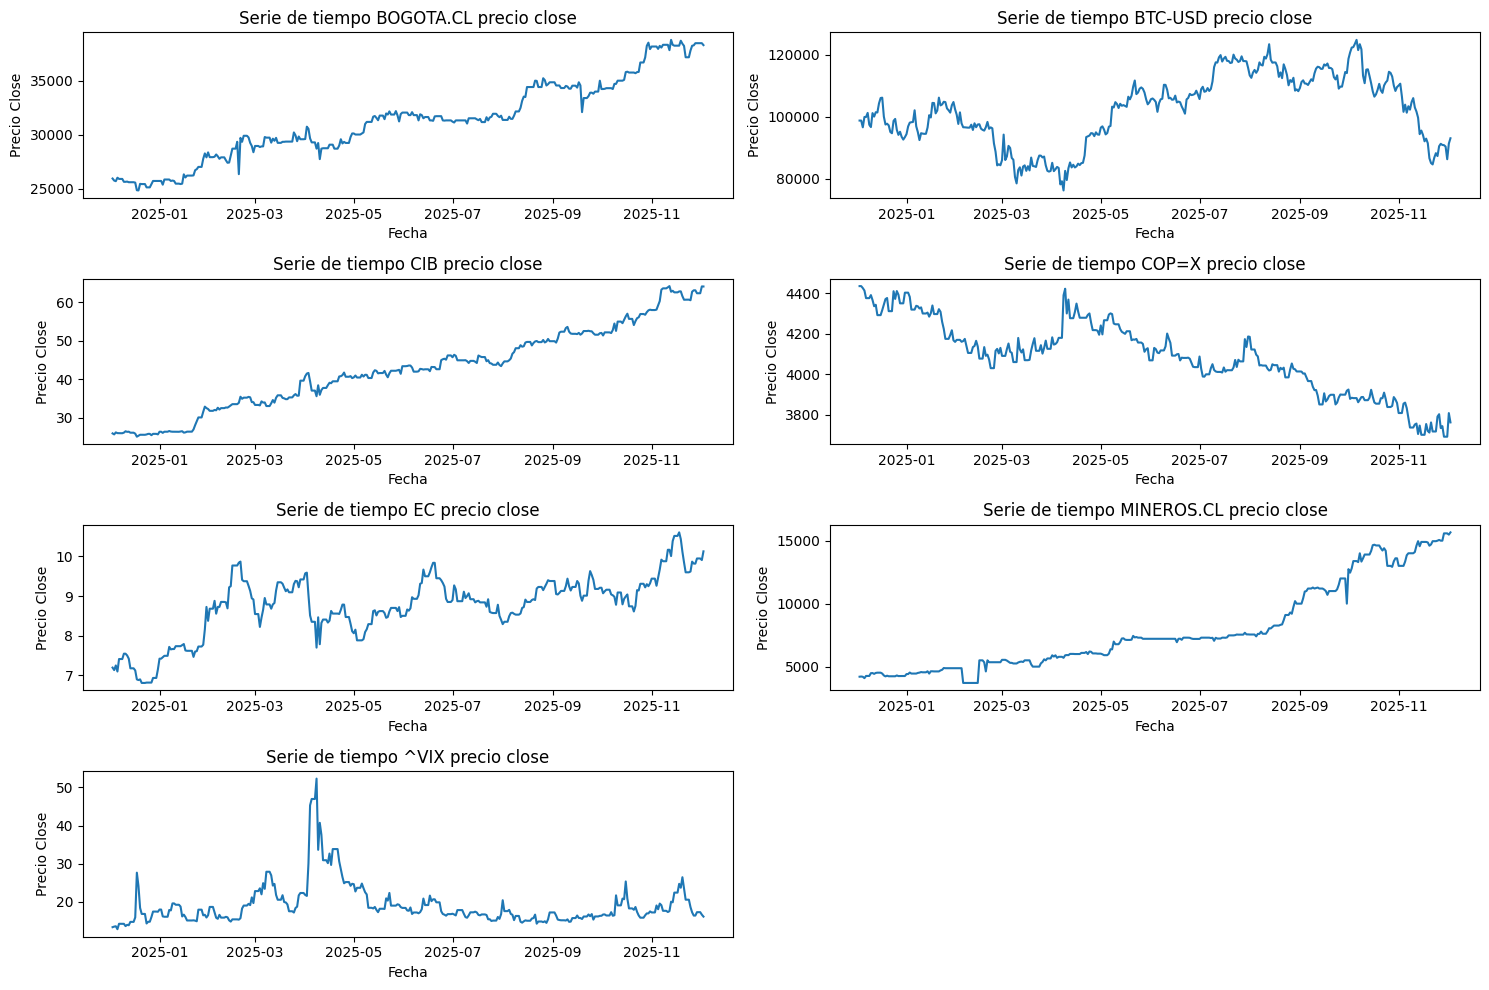

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
for i, column in enumerate(close_data.columns):
    plt.subplot(len(close_data.columns) // 2 + 1, 2, i + 1)
    sns.lineplot(x=close_data.index, y=close_data[column])
    plt.title(f'Serie de tiempo {column} precio close')
    plt.xlabel('Fecha')
    plt.ylabel('Precio Close')
plt.tight_layout()
plt.show()

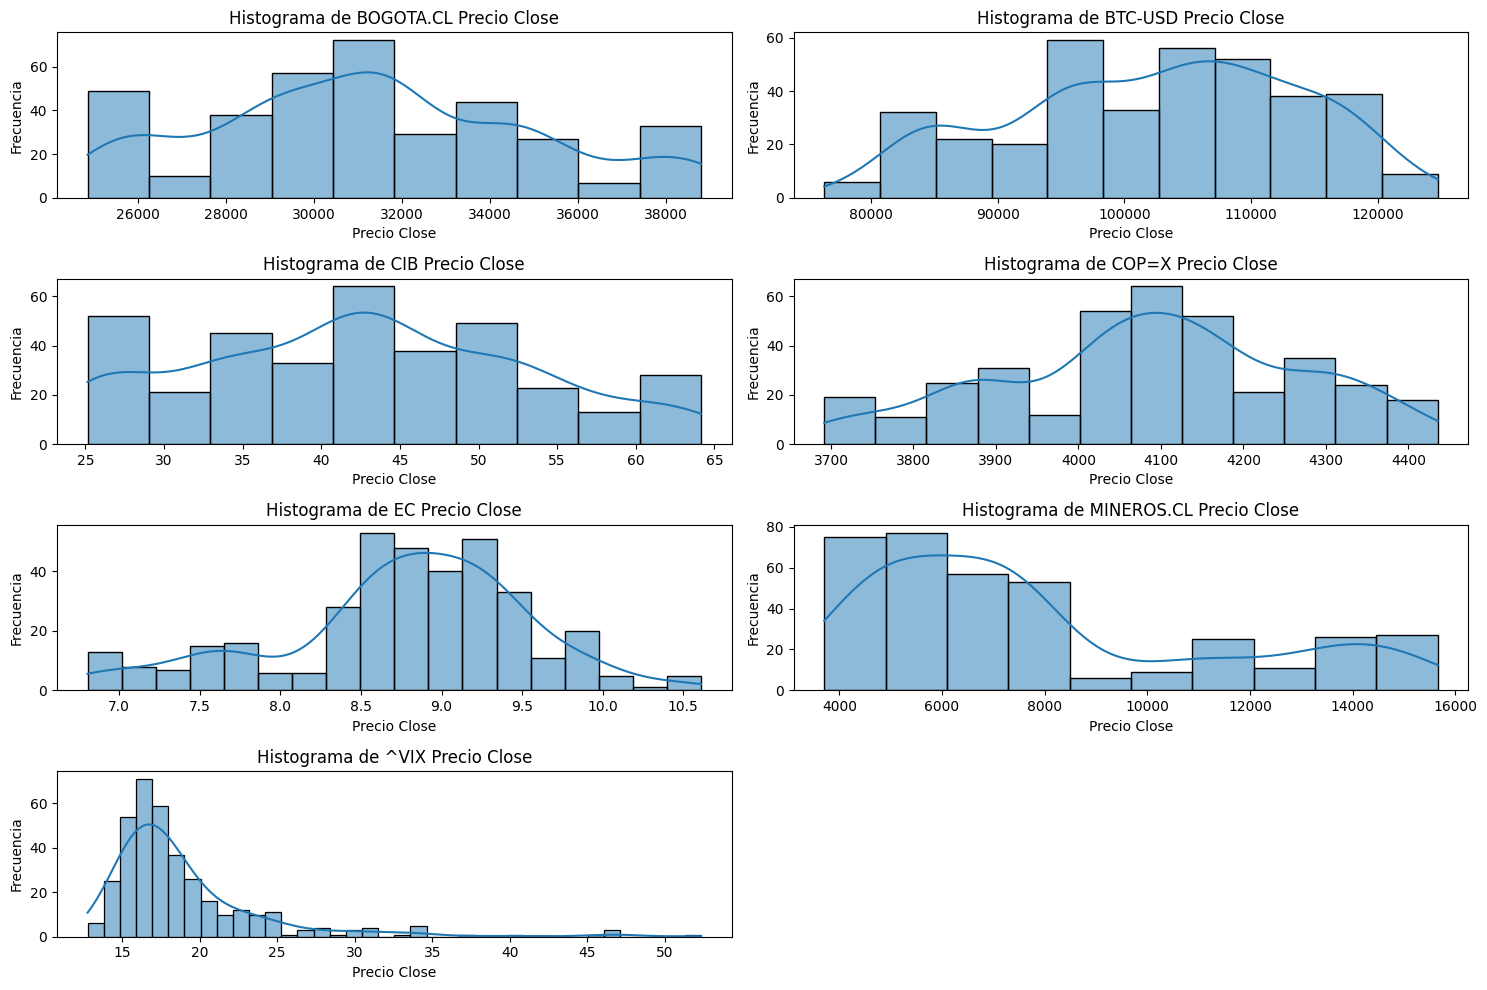

In [ ]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(close_data.columns):
    plt.subplot(len(close_data.columns) // 2 + 1, 2, i + 1)
    sns.histplot(close_data[column], kde=True)
    plt.title(f'Histograma de {column} Precio Close')
    plt.xlabel('Precio Close')
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

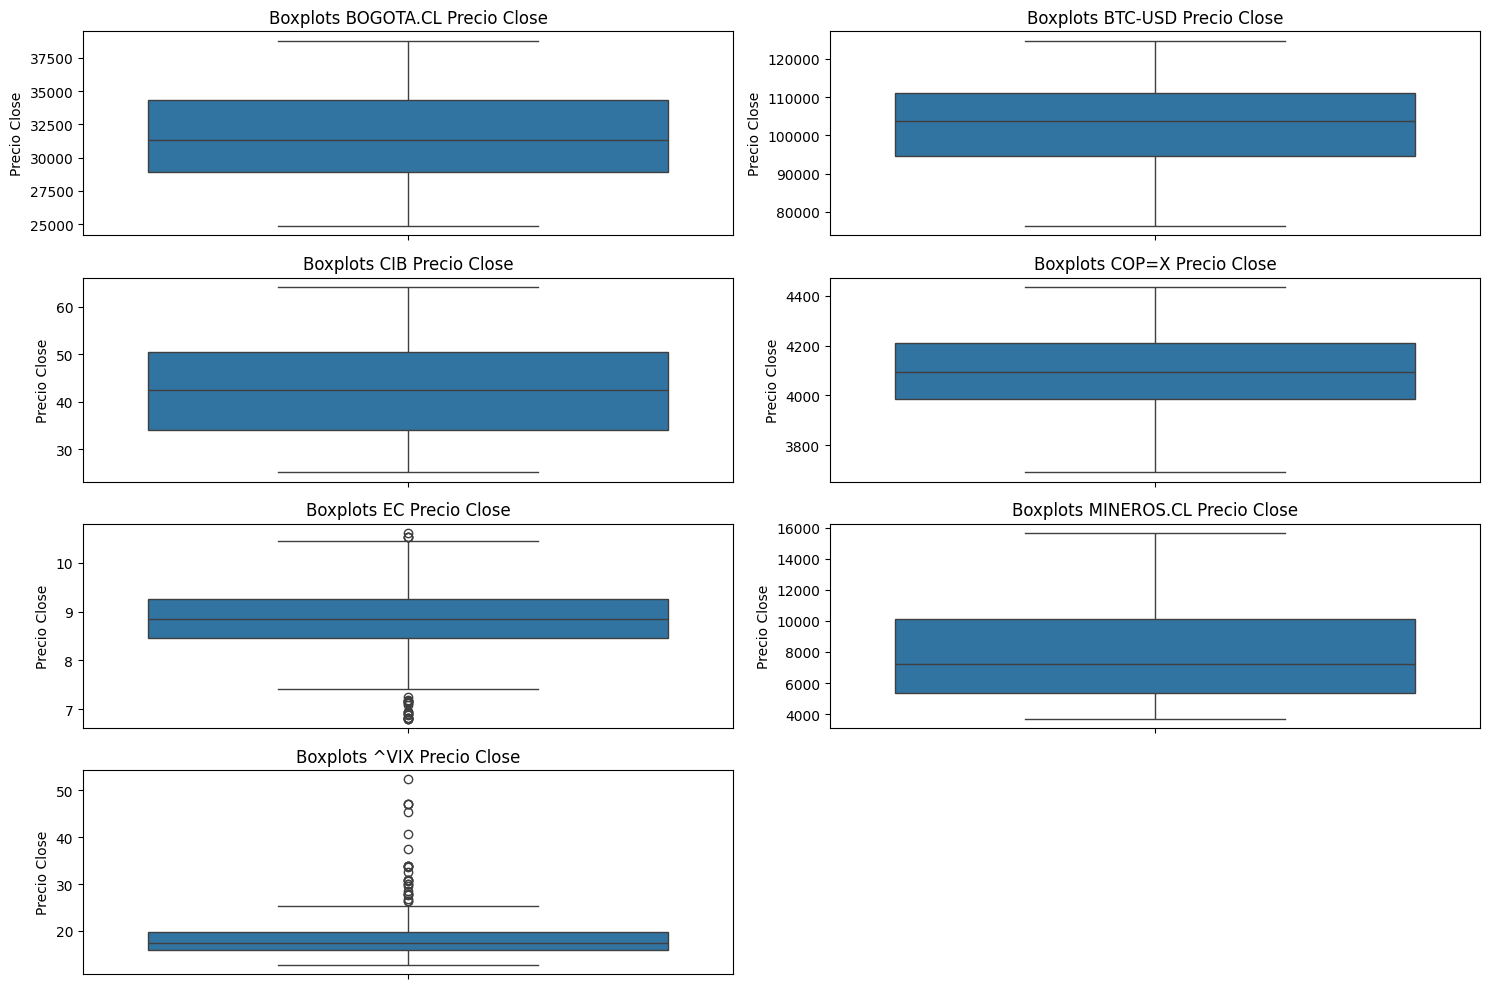

In [ ]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(close_data.columns):
    plt.subplot(len(close_data.columns) // 2 + 1, 2, i + 1)
    sns.boxplot(y=close_data[column])
    plt.title(f'Boxplots {column} Precio Close')
    plt.ylabel('Precio Close')
plt.tight_layout()
plt.show()

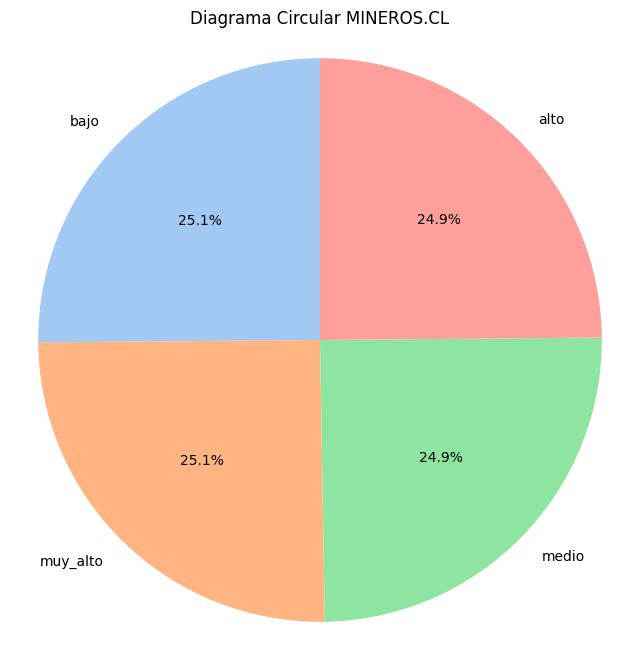

In [ ]:
plt.figure(figsize=(8, 8))
volume_category_counts = data['Volume', 'catvolumeMINEROS.CL'].value_counts()
plt.pie(volume_category_counts, labels=volume_category_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Diagrama Circular MINEROS.CL')
plt.axis('equal')
plt.show()

In [ ]:
## 7. Matriz de correllación de las variables

corr_k = data.corr(method="kendall", numeric_only=True)

corr_k

Price                  Index     Close                                \
Ticker                       BOGOTA.CL   BTC-USD       CIB     COP=X   
Price   Ticker                                                         
Index               1.000000  0.826358  0.331554  0.920433 -0.727813   
Close   BOGOTA.CL   0.826358  1.000000  0.303005  0.823092 -0.688623   
        BTC-USD     0.331554  0.303005  1.000000  0.327119 -0.289317   
        CIB         0.920433  0.823092  0.327119  1.000000 -0.731755   
        COP=X      -0.727813 -0.688623 -0.289317 -0.731755  1.000000   
        EC          0.497536  0.516772  0.061911  0.529329 -0.602333   
        MINEROS.CL  0.907917  0.810481  0.351417  0.879906 -0.690145   
        ^VIX       -0.039701 -0.053721 -0.400010 -0.058369  0.088604   
Volume  BOGOTA.CL  -0.016959  0.005001 -0.065391 -0.010746 -0.049711   
        BTC-USD     0.207622  0.214329  0.245950  0.196439 -0.155511   
        CIB        -0.034992 -0.021997 -0.210537 -0.029142  0.056278   
        COP=X            NaN       NaN       NaN       NaN       NaN   
        EC         -0.189645 -0.197696 -0.256405 -0.185853  0.142349   
        MINEROS.CL  0.223780  0.202138  0.002601  0.225127 -0.213679   
        ^VIX             NaN       NaN       NaN       NaN       NaN   
BTC-COP             0.117764  0.102394  0.745007  0.111129 -0.033998   

Price                                                Volume            \
Ticker                    EC MINEROS.CL      ^VIX BOGOTA.CL   BTC-USD   
Price   Ticker                                                          
Index               0.497536   0.907917 -0.039701 -0.016959  0.207622   
Close   BOGOTA.CL   0.516772   0.810481 -0.053721  0.005001  0.214329   
        BTC-USD     0.061911   0.351417 -0.400010 -0.065391  0.245950   
        CIB         0.529329   0.879906 -0.058369 -0.010746  0.196439   
        COP=X      -0.602333  -0.690145  0.088604 -0.049711 -0.155511   
        EC          1.000000   0.472659  0.013758  0.069903  0.010581   
        MINEROS.CL  0.472659   1.000000 -0.025948 -0.021195  0.229620   
        ^VIX        0.013758  -0.025948  1.000000  0.041212 -0.130457   
Volume  BOGOTA.CL   0.069903  -0.021195  0.041212  1.000000  0.036155   
        BTC-USD     0.010581   0.229620 -0.130457  0.036155  1.000000   
        CIB         0.028827  -0.031472  0.246003  0.116236 -0.134856   
        COP=X            NaN        NaN       NaN       NaN       NaN   
        EC         -0.054406  -0.192762  0.195862  0.201536 -0.051137   
        MINEROS.CL  0.225072   0.258955  0.043572  0.133151  0.062966   
        ^VIX             NaN        NaN       NaN       NaN       NaN   
BTC-COP            -0.139416   0.153963 -0.405529 -0.083401  0.239004   

Price                                                          BTC-COP  
Ticker                   CIB COP=X        EC MINEROS.CL ^VIX            
Price   Ticker                                                          
Index              -0.034992   NaN -0.189645   0.223780  NaN  0.117764  
Close   BOGOTA.CL  -0.021997   NaN -0.197696   0.202138  NaN  0.102394  
        BTC-USD    -0.210537   NaN -0.256405   0.002601  NaN  0.745007  
        CIB        -0.029142   NaN -0.185853   0.225127  NaN  0.111129  
        COP=X       0.056278   NaN  0.142349  -0.213679  NaN -0.033998  
        EC          0.028827   NaN -0.054406   0.225072  NaN -0.139416  
        MINEROS.CL -0.031472   NaN -0.192762   0.258955  NaN  0.153963  
        ^VIX        0.246003   NaN  0.195862   0.043572  NaN -0.405529  
Volume  BOGOTA.CL   0.116236   NaN  0.201536   0.133151  NaN -0.083401  
        BTC-USD    -0.134856   NaN -0.051137   0.062966  NaN  0.239004  
        CIB         1.000000   NaN  0.201982   0.047317  NaN -0.219652  
        COP=X            NaN   1.0       NaN        NaN  NaN       NaN  
        EC          0.201982   NaN  1.000000   0.017884  NaN -0.234278  
        MINEROS.CL  0.047317   NaN  0.017884   1.000000  NaN -0.081344  
  

In [ ]:
### 8. Ajuste una media movil para una de los activos como estrategia predictora y calcule las estadisticas del error

import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# Calcular media móvil de 3 periodos
# Asigna la nueva columna usando un MultiIndex para que se integre correctamente
data[('Price', "MINEROS.CLM5")] = data['Close']["MINEROS.CL"].rolling(window=5).mean().shift(1).fillna(data['Close']["MINEROS.CL"].iloc[0:4].mean())

# Preparar datos (eliminar NaN de la nueva columna para el cálculo de métricas)
# Usa el nombre de la columna MultiIndex para subset
datos_ma5 = data.dropna(subset=[('Price', "MINEROS.CLM5")])

# Las 'predicciones' son ahora los valores de la media móvil
y_pred_ma = datos_ma5[('Price', "MINEROS.CLM5")].values

# Alinear los valores originales de 'MINEROS.CL' con la longitud de los datos de la media móvil
y_original_aligned = datos_ma5['Close']['MINEROS.CL'].values

# Parámetros y métricas
# En este enfoque de media móvil directa, no hay 'pendiente' ni 'intercepto' de un modelo de regresión
# Sin embargo, aún podemos calcular R2 y RMSE comparando la MA con los datos originales

r2 = r2_score(y_original_aligned, y_pred_ma)
rmse = np.sqrt(mean_squared_error(y_original_aligned, y_pred_ma))

print("="*50)
print("ESTRATEGIA PREDICTORIA: MEDIA MÓVIL (5 PERIODOS)")
print("="*50)
print(f"El pronóstico es directamente la Media Móvil de 5 períodos.")
print(f"\nMÉTRICAS DE RENDIMIENTO (vs. valores originales alineados):")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Observaciones: {len(y_original_aligned)}")

ESTRATEGIA PREDICTORIA: MEDIA MÓVIL (5 PERIODOS)
El pronóstico es directamente la Media Móvil de 5 períodos.

MÉTRICAS DE RENDIMIENTO (vs. valores originales alineados):
R²: 0.9899
RMSE: 342.6826
Observaciones: 366


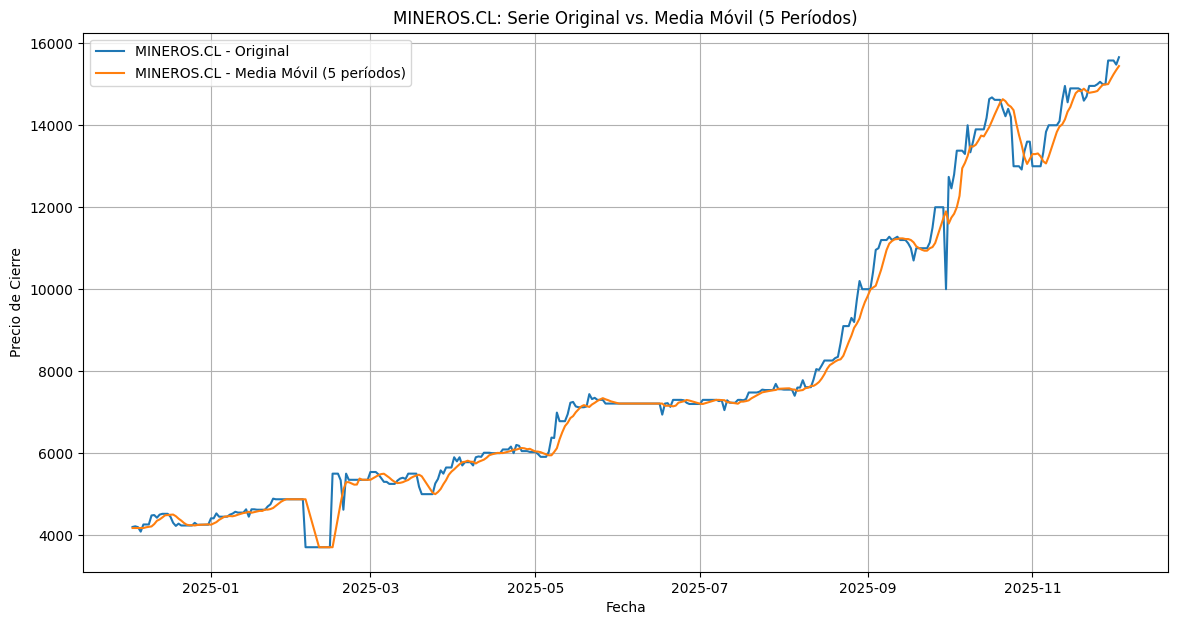

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(x=datos_ma5.index, y=datos_ma5['Close']['MINEROS.CL'], label='MINEROS.CL - Original')
sns.lineplot(x=datos_ma5.index, y=datos_ma5[('Price', 'MINEROS.CLM5')], label='MINEROS.CL - Media Móvil (5 períodos)')
plt.title('MINEROS.CL: Serie Original vs. Media Móvil (5 Períodos)')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
data

Price      Index         Close                                        \
Ticker               BOGOTA.CL       BTC-USD        CIB        COP=X   
Date                                                                   
2024-12-03     1  25951.517578  98768.531250  25.990852  4435.500000   
2024-12-04     2  25760.832031  98768.531250  25.727993  4435.500000   
2024-12-05     3  25703.628906  96593.570312  26.253704  4425.750000   
2024-12-06     4  26027.785156  99920.710938  26.062538  4413.669922   
2024-12-07     5  25913.376953  99923.335938  26.038641  4376.152344   
...          ...           ...           ...        ...          ...   
2025-11-29   362  38500.000000  90851.757812  62.299999  3691.856689   
2025-11-30   363  38500.000000  90394.312500  62.299999  3691.856689   
2025-12-01   364  38500.000000  86321.570312  62.299999  3691.856689   
2025-12-02   365  38500.000000  91350.203125  64.070000  3808.399902   
2025-12-03   366  38320.000000  93073.062500  64.050003  3762.469971   

Price                                         Volume                          \
Ticker             EC    MINEROS.CL   ^VIX BOGOTA.CL       BTC-USD       CIB   
Date                                                                           
2024-12-03   7.191358   4199.937500  13.30    3741.0  7.719982e+10  197600.0   
2024-12-04   7.128197   4214.937500  13.45    9416.0  7.719982e+10  264800.0   
2024-12-05   7.245496   4194.937500  13.54   21791.0  1.492189e+11  254500.0   
2024-12-06   7.092104   4084.938965  12.77     504.0  9.453477e+10  173800.0   
2024-12-07   7.407911   4259.936523  14.19   14767.0  4.417751e+10  196300.0   
...               ...           ...    ...       ...           ...       ...   
2025-11-29   9.950000  15580.000000  17.24    7265.0  3.792177e+10  257100.0   
2025-11-30   9.950000  15580.000000  17.24    7265.0  3.849790e+10  257100.0   
2025-12-01   9.950000  15580.000000  17.24    7265.0  8.796289e+10  257100.0   
2025-12-02   9.910000  15480.000000  16.59    3095.0  7.854680e+10  271800.0   
2025-12-03  10.130000  15660.000000  16.08    8808.0  7.677981e+10  202665.0   

Price                                                                 BTC-COP  \
Ticker     COP=X         EC MINEROS.CL ^VIX catvolumeMINEROS.CL                 
Date                                                                            
2024-12-03   0.0  1502100.0   101572.0  0.0               medio  4.380878e+08   
2024-12-04   0.0  1713900.0    38725.0  0.0                bajo  4.380878e+08   
2024-12-05   0.0  1803900.0    34344.0  0.0                bajo  4.274990e+08   
2024-12-06   0.0  2430300.0    87237.0  0.0               medio  4.410170e+08   
2024-12-07   0.0  3721300.0   103641.0  0.0               medio  4.372797e+08   
...          ...        ...        ...  ...                 ...           ...   
2025-11-29   0.0  1872800.0   323173.0  0.0            muy_alto  3.354117e+08   
2025-11-30   0.0  1872800.0   323173.0  0.0            muy_alto  3.337228e+08   
2025-12-01   0.0  1872800.0   323173.0  0.0            muy_alto  3.186869e+08   
2025-12-02   0.0  1593100.0   163392.0  0.0                alto  3.478981e+08   
2025-12-03   0.0  1351183.0    94842.0  0.0               medio  3.501846e+08   

Price              Price  
Ticker      MINEROS.CLM5  
Date                      
2024-12-03   4173.687866  
2024-12-04   4173.687866  
2024-12-05   4173.687866  
2024-12-06   4173.687866  
2024-12-07   4173.687866  
...                  ...  
2025-11-29  15004.000000  
2025-11-30  15128.000000  
2025-12-01  15244.000000  
2025-12-02  15348.000000  
2025-12-03  15444.000000  

[366 rows x 18 columns]

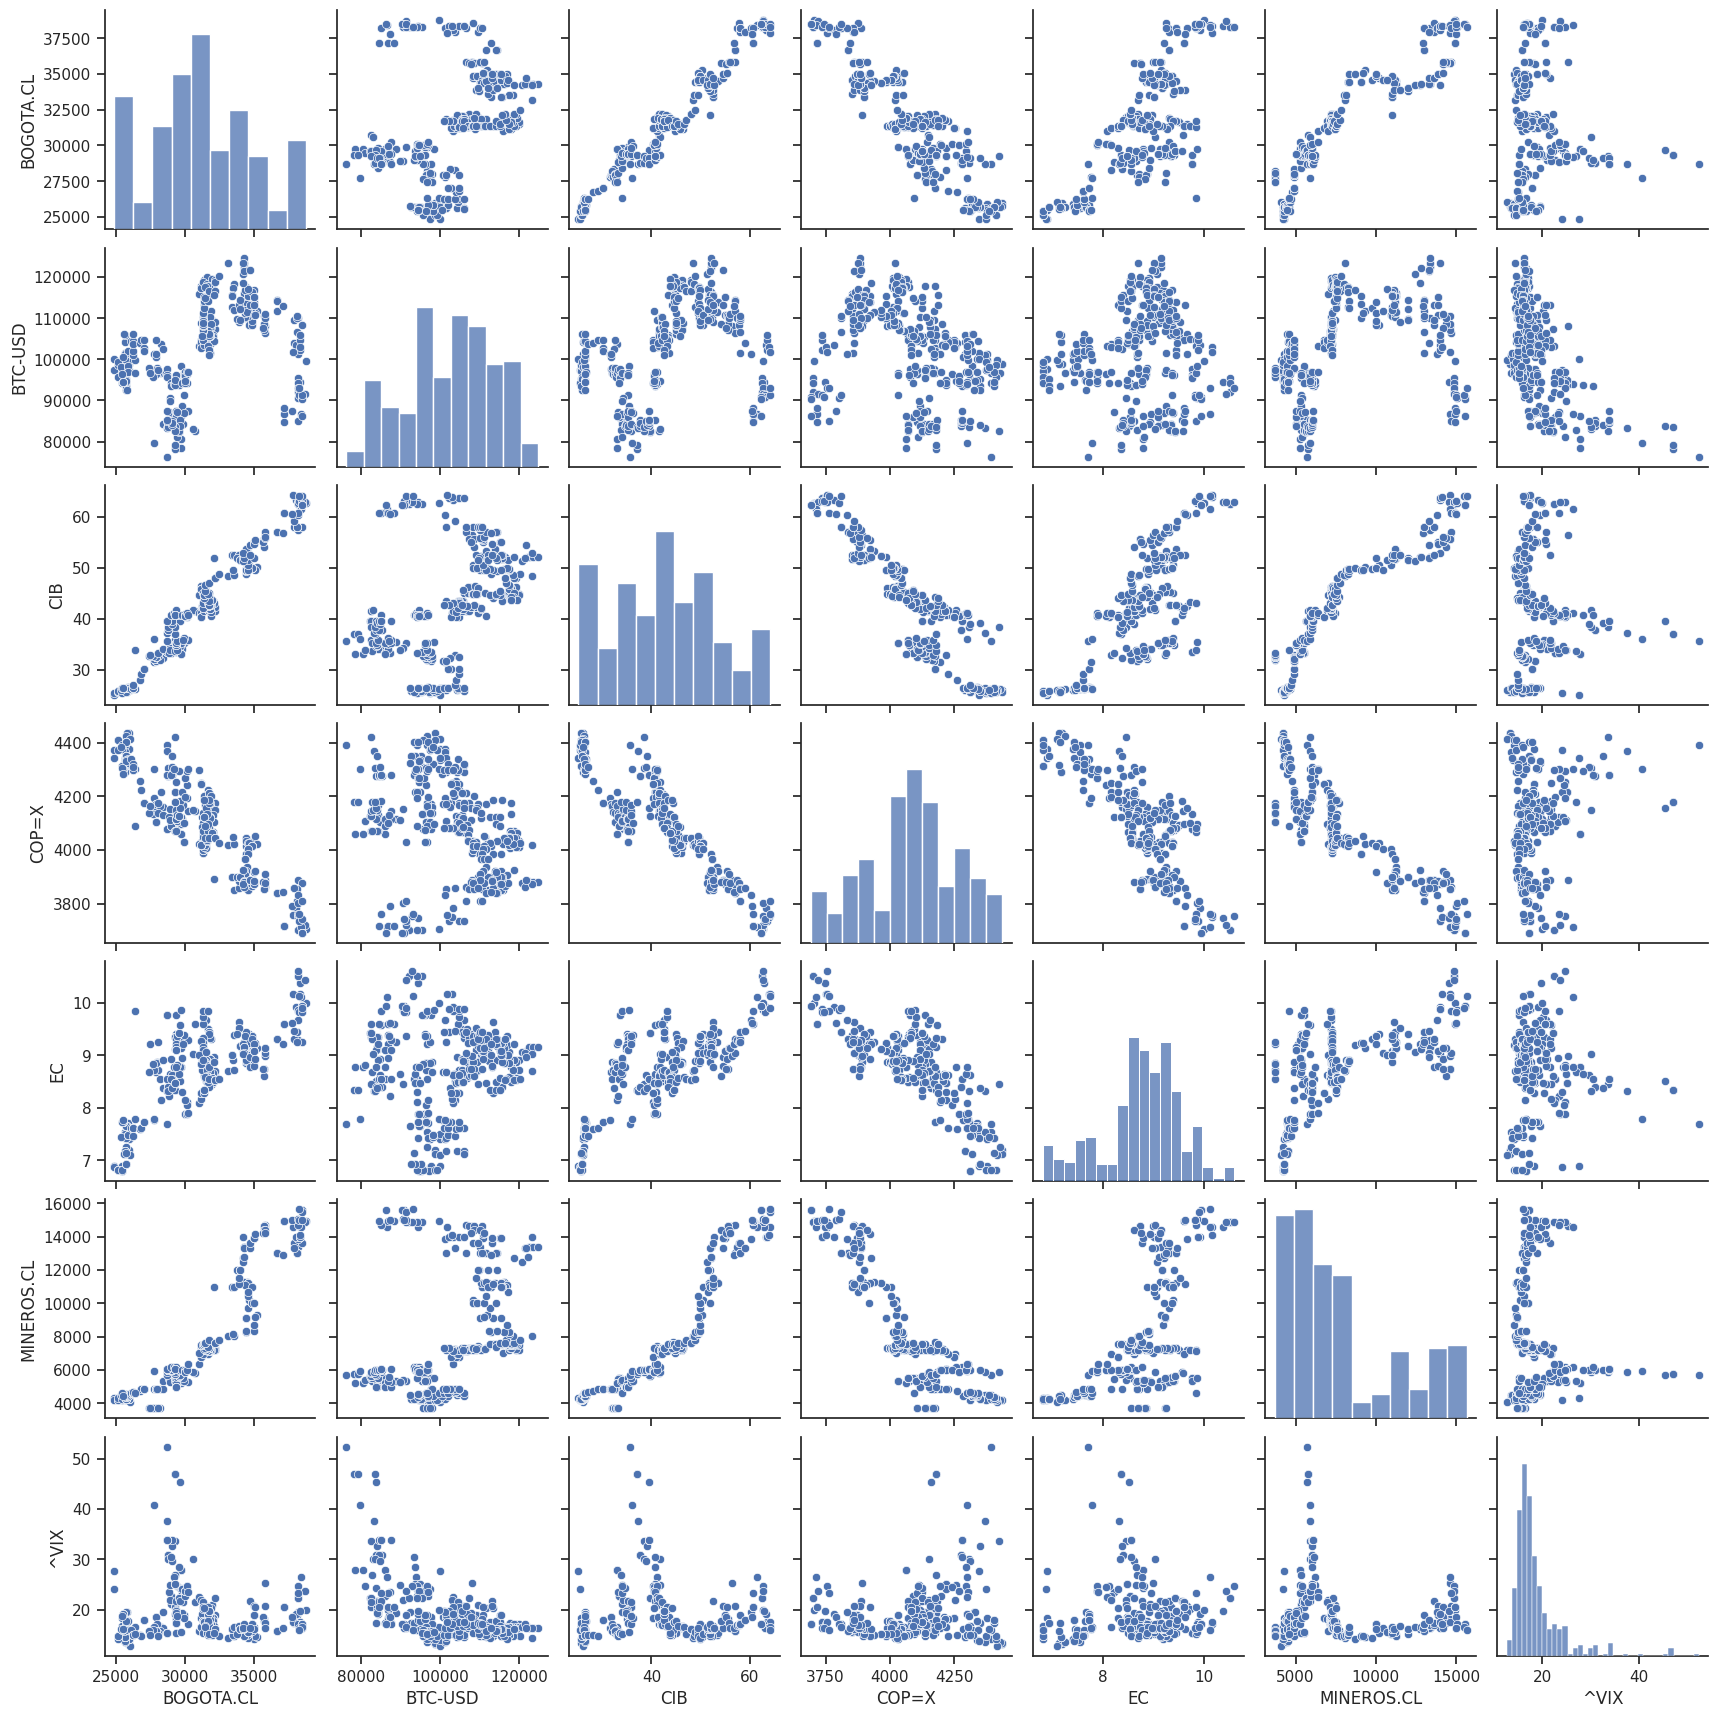

In [ ]:
##9. Realice una matriz de gráficos donde se visualicen los diagramas de dispersión entre los valores "Close" de las Variables

import seaborn as sns
sns.set(style="ticks")

sns.pairplot(data["Close"])


In [ ]:
###10. Realice una regresión lineal de la criptomoneda en función de otro de los activos y calcule el ajuste del modelo.

# Escogemos nuestra variable predictora como BOGOTA.CL:
X=data["Close"]['BOGOTA.CL'].values.reshape(-1,1)

# Escogemos nuestra variable objetivo  CIB:
y=data["Close"]['CIB'].values.reshape(-1,1)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

#seleccionamos los datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=3)

#entrenamos el modelo
linear  = LinearRegression()
linear.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = linear.predict(X_test)

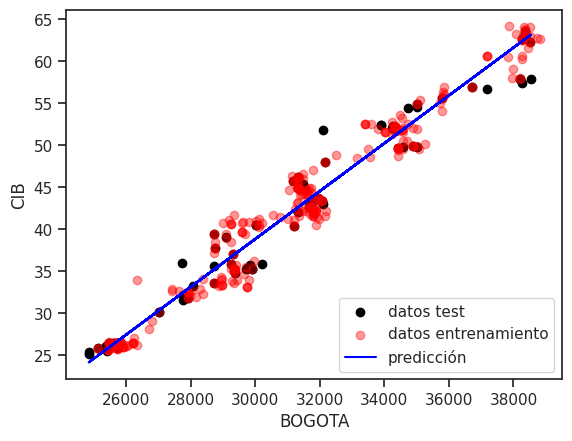

MAE:  1.8432090024737884
MSE:  5.357826565164899
RMSE:  2.3146979425326535
R2:  0.9528277092402476


In [ ]:
plt.scatter(X_test, y_test,  color='black',label=r'datos test')
plt.scatter(X_train, y_train,  color='red',alpha=0.4,label=r'datos entrenamiento')
plt.plot(X_test, y_pred, color='blue',label=r'predicción')
plt.legend(loc='lower right')
plt.xlabel(r'BOGOTA')
plt.ylabel(r'CIB')
plt.show()

print('MAE: ', metrics.mean_absolute_error(y_test, y_pred))
print('MSE: ', metrics.mean_squared_error(y_test, y_pred))
print('RMSE: ', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('R2: ', metrics.r2_score(y_test, y_pred))